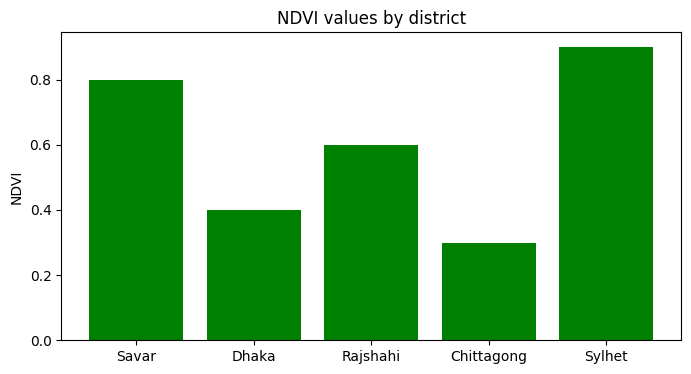

In [1]:
# Install geopandas (only needed once)
!pip install geopandas --quiet
!pip install matplotlib --quiet

# Now draw a simple graph
import matplotlib.pyplot as plt

ndvi_values = [0.8, 0.4, 0.6, 0.3, 0.9]
districts = ["Savar", "Dhaka", "Rajshahi", "Chittagong", "Sylhet"]

plt.figure(figsize=(8, 4))
plt.bar(districts, ndvi_values, color="green")
plt.title("NDVI values by district")
plt.ylabel("NDVI")
plt.show()

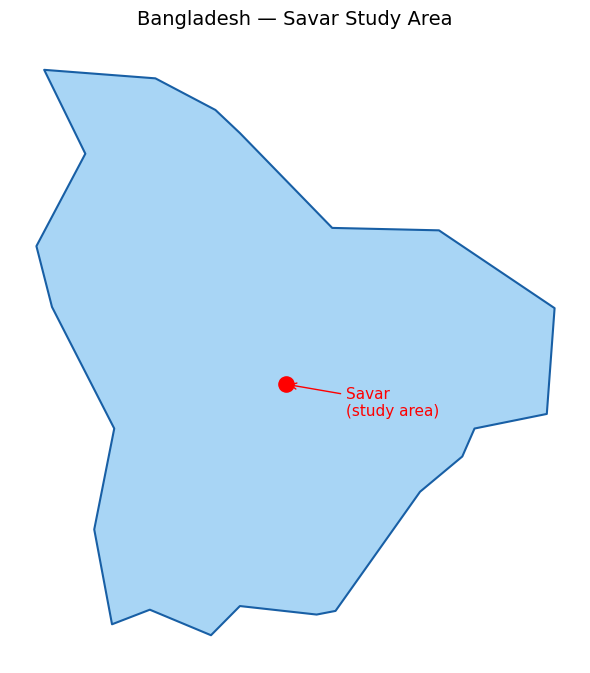

Map done! Your Week 1 deliverable is ready.


In [11]:
from shapely.geometry import Polygon, Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Bangladesh boundary coordinates (hardcoded — no download needed!)
bangladesh_coords = [
    (88.08, 26.45), (89.08, 26.38), (89.62, 26.12), (89.84, 25.93),
    (90.67, 25.15), (91.63, 25.13), (92.67, 24.49), (92.60, 23.62),
    (91.95, 23.50), (91.84, 23.27), (91.46, 22.98), (90.70, 22.00),
    (90.53, 21.97), (89.84, 22.04), (89.58, 21.80), (89.03, 22.01),
    (88.69, 21.89), (88.53, 22.67), (88.71, 23.50), (88.15, 24.50),
    (88.01, 25.00), (88.45, 25.76), (88.08, 26.45)
]

# Build the country shape
country = gpd.GeoDataFrame(
    {'name': ['Bangladesh']},
    geometry=[Polygon(bangladesh_coords)],
    crs="EPSG:4326"
)

# Savar location as a point (your study area!)
savar_point = gpd.GeoDataFrame(
    {'name': ['Savar']},
    geometry=[Point(90.26, 23.86)],
    crs="EPSG:4326"
)

# Draw the map
fig, ax = plt.subplots(figsize=(6, 9))

# Bangladesh in blue
country.plot(ax=ax, color="#A8D5F5", edgecolor="#185FA5", linewidth=1.5)

# Savar as a red dot
savar_point.plot(ax=ax, color="red", markersize=120, zorder=5)

# Label it
ax.annotate("Savar\n(study area)", xy=(90.26, 23.86),
            xytext=(90.8, 23.6),
            fontsize=11, color="red",
            arrowprops=dict(arrowstyle="->", color="red"))

ax.set_title("Bangladesh — Savar Study Area", fontsize=14, pad=12)
ax.axis("off")
plt.tight_layout()
plt.show()

print("Map done! Your Week 1 deliverable is ready.")

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

# GADM - direct download, no Git LFS, works in Colab
# ADM1 = divisions (7 big regions), easier to load than 64 districts
!wget -q "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BGD_1.json" -O bgd_divisions.json

print("Download done! Now reading...")

gdf = gpd.read_file("bgd_divisions.json")
print("Loaded! Found:", len(gdf), "divisions")
print(gdf["NAME_1"].tolist())

Download done! Now reading...
Loaded! Found: 8 divisions
['Barisal', 'Chittagong', 'Dhaka', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet']


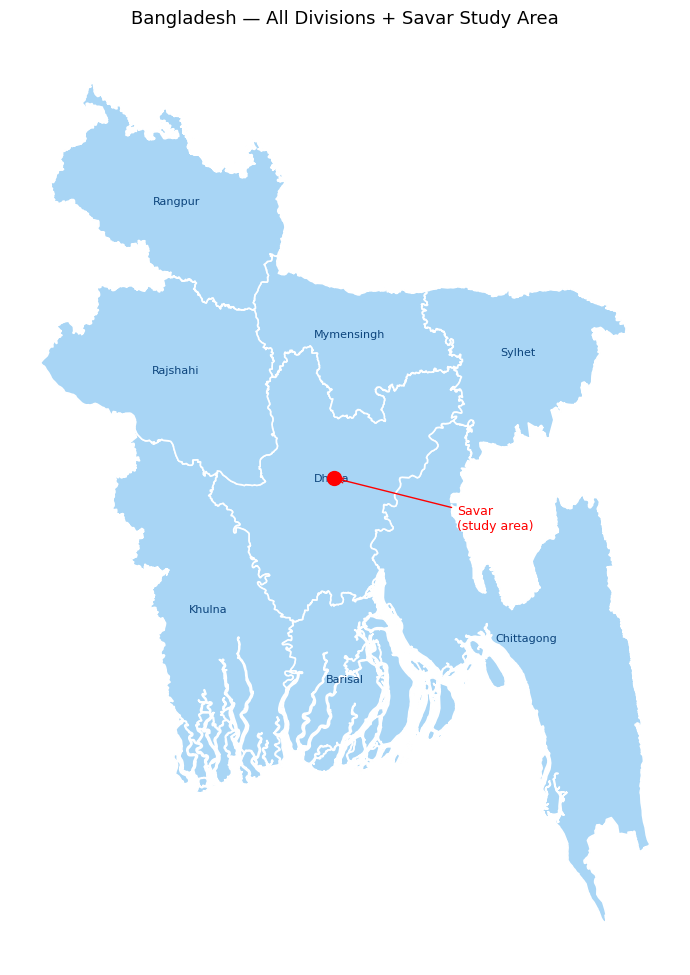

In [13]:
fig, ax = plt.subplots(figsize=(7, 10))

# All divisions in light blue
gdf.plot(ax=ax, color="#A8D5F5", edgecolor="white", linewidth=1.2)

# Label each division
for _, row in gdf.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.annotate(row["NAME_1"], xy=(x, y),
                fontsize=8, ha="center", color="#0C447C")

# Savar red dot (it's inside Dhaka division)
ax.plot(90.26, 23.86, "ro", markersize=10, zorder=5)
ax.annotate("Savar\n(study area)", xy=(90.26, 23.86),
            xytext=(91.2, 23.5), fontsize=9, color="red",
            arrowprops=dict(arrowstyle="->", color="red"))

ax.set_title("Bangladesh — All Divisions + Savar Study Area", fontsize=13, pad=12)
ax.axis("off")
plt.tight_layout()
plt.show()

# 🌾 SentinelCropGuard
### Week 1 — Project Setup & Bangladesh Map

> **Course:** CSE 299 — Junior Design Project  
> **Study Area:** Savar, Dhaka Division, Bangladesh  
> **Data Source:** Sentinel-2 (coming Week 2), GADM Administrative Boundaries  
> **Stack:** Python · Google Colab · GeoPandas · Matplotlib

---

## 📌 What This Project Does

SentinelCropGuard is a satellite-based crop stress detection system for Bangladesh. It uses **Sentinel-2 multispectral imagery** to detect unhealthy vegetation patterns across rice-growing regions — helping farmers and government agencies identify disease risk early, before it spreads.

**The full pipeline (built over 10 weeks):**

```
Sentinel-2 Satellite Images
        ↓
Cloud Masking + NDVI Computation
        ↓
Patch-level Feature Extraction
        ↓
ML / Deep Learning Model
        ↓
Severity Map (Healthy / Mild / Moderate / Severe)
        ↓
Streamlit Web App + Explainability (SHAP)
```

> Week 1 focuses on **setup only** — no AI yet. Just tools, Python basics, and maps.

---

## ✅ Week 1 Goals

| Goal | Status |
|------|--------|
| Set up Google Colab | ✅ Done |
| Learn Python basics (variables, lists, functions) | ✅ Done |
| Plot a simple bar chart | ✅ Done |
| Download Bangladesh boundary data (GADM) | ✅ Done |
| Draw a labeled map with Savar marked | ✅ Done |

---

## 📁 File Structure

```
SentinelCropGuard/
│
├── notebooks/
│   └── Week1_SentinelCropGuard.ipynb   ← main notebook this week
│
├── data/
│   └── bgd_divisions.json              ← Bangladesh division boundaries (GADM)
│
├── results/
│   └── (screenshots of outputs go here)
│
└── README.md                           ← this file
```

---

## 🗺️ Output: Bangladesh Map

The map shows all **7 administrative divisions** of Bangladesh with **Savar** (the chosen study area) marked as a red point inside Dhaka Division.

**Why Savar?**
- Major agricultural zone near Dhaka
- Mix of rice fields and peri-urban land — good contrast for stress detection
- Well-documented area with available Sentinel-2 coverage

---

## 🛠️ How to Run

### Step 1 — Open in Google Colab
Open the notebook `Week1_SentinelCropGuard.ipynb` in [Google Colab](https://colab.google).

### Step 2 — Install dependencies (Cell 1)
```python
!pip install geopandas --quiet
!pip install matplotlib --quiet
```

### Step 3 — Download Bangladesh boundary data (Cell 2)
```python
!wget -q "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BGD_1.json" -O bgd_divisions.json

import geopandas as gpd
gdf = gpd.read_file("bgd_divisions.json")
print("Loaded:", len(gdf), "divisions")
```

### Step 4 — Draw the map (Cell 3)
```python
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 10))

gdf.plot(ax=ax, color="#A8D5F5", edgecolor="white", linewidth=1.2)

for _, row in gdf.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.annotate(row["NAME_1"], xy=(x, y), fontsize=8, ha="center", color="#0C447C")

# Savar study area
ax.plot(90.26, 23.86, "ro", markersize=10, zorder=5)
ax.annotate("Savar\n(study area)", xy=(90.26, 23.86),
            xytext=(91.2, 23.5), fontsize=9, color="red",
            arrowprops=dict(arrowstyle="->", color="red"))

ax.set_title("Bangladesh — All Divisions + Savar Study Area", fontsize=13, pad=12)
ax.axis("off")
plt.tight_layout()
plt.show()
```

---

## 🧠 Python Concepts Learned This Week

| Concept | What It Means | Example |
|---------|--------------|---------|
| Variable | A named box that holds a value | `ndvi = 0.75` |
| List | A collection of items in order | `districts = ["Savar", "Dhaka"]` |
| Function | A reusable set of steps | `def check_health(ndvi):` |
| Import | Borrow a tool someone else built | `import geopandas as gpd` |
| Plot | Draw a graph or chart | `plt.plot(values)` |

---

## 📦 Libraries Used

| Library | Purpose |
|---------|---------|
| `geopandas` | Read and draw geographic data (maps) |
| `matplotlib` | Draw charts and graphs |
| `shapely` | Handle geometry (points, polygons) |

---

## 🗓️ What's Coming Next

| Week | Topic |
|------|-------|
| **Week 2** | Load real Sentinel-2 satellite images for Savar using Google Earth Engine |
| **Week 3** | Compute NDVI (vegetation health index) and create a health map |
| **Week 4** | Build first ML model — healthy vs stressed classifier |
| **Week 5** | Convert predictions into a spatial risk map |
| Weeks 6–10 | Severity levels, deep learning, explainability, web app |

---

## ⚠️ Limitations of Week 1

- Map uses **division-level** boundaries (7 regions), not district-level (64 districts) — GADM district data uses Git LFS which Colab cannot read directly
- No real satellite data yet — that begins Week 2
- Savar is marked as an approximate point, not an exact boundary polygon

---

## 📝 Progress Summary

> This week I set up Google Colab and learned Python basics including variables, lists, and functions. I installed geopandas and matplotlib, then downloaded Bangladesh administrative boundary data from GADM. I created a labeled map of all 7 divisions of Bangladesh with the Savar study area marked as the target region. Next step is loading Sentinel-2 satellite imagery for Savar using Google Earth Engine.

---

*SentinelCropGuard — CSE 299 Junior Design Project*